# Week 5: Scenario Analysis (Optional)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Self-contained: load Week 2's feature set (new kernel, nothing carried over from Week 4)
df_model = pd.read_csv('ghg_features.csv')
PROJECT_COUNTRIES = sorted(df_model['country'].unique())

train_df = df_model[df_model['year'].between(1990, 2018)].copy()

print(f"Countries: {len(PROJECT_COUNTRIES)} | Historical years available: "
      f"{df_model['year'].min()}–{df_model['year'].max()}")

Countries: 10 | Historical years available: 1990–2024


In [2]:
# ── Recompute Week 4's ETS(A,Ad,N) BAU forecast (self-contained; not carried over from Week 4's kernel) ──

def forecast_with_ci(fit, steps, start_year, n_sims=1000, alpha=0.05, seed=42):
    idx = pd.RangeIndex(start_year, start_year + steps)
    try:
        fc_result = fit.get_forecast(steps)
        mean_fc = pd.Series(fc_result.predicted_mean.values, index=idx)
    except Exception:
        mean_fc = pd.Series(fit.forecast(steps).values, index=idx)
    return mean_fc

FORECAST_START = 2019
FORECAST_END = 2043
FORECAST_STEPS = FORECAST_END - FORECAST_START + 1

bau_forecast = {}
for country in PROJECT_COUNTRIES:
    train_co2 = (
        train_df[train_df['country'] == country]
        .sort_values('year')
        .set_index('year')['co2']
        .dropna()
    )
    model = ExponentialSmoothing(train_co2, trend='add', damped_trend=True, seasonal=None)
    fit = model.fit(optimized=True)
    bau_forecast[country] = forecast_with_ci(fit, FORECAST_STEPS, FORECAST_START)

print("BAU (Business-as-Usual) ETS forecast rebuilt for", len(bau_forecast), "countries,",
      f"covering {FORECAST_START}–{FORECAST_END}.")

BAU (Business-as-Usual) ETS forecast rebuilt for 10 countries, covering 2019–2043.


### 5.1 Scenario Design

- **Scenario A — Business as Usual (BAU):** no policy change; uses the ETS(A,Ad,N) forecast from Week 4 as-is.
- **Scenario B — Moderate Mitigation:** applies a compounding 2% annual reduction to the BAU forecast, starting in 2025. Each year's value is 2% lower than what it would otherwise have been under BAU, compounding forward (i.e. `BAU_year × (1 − 0.02)^(year − 2024)`).
- **Scenario C — Aggressive Mitigation:** same compounding logic, but at a 5% annual reduction rate.

**Basis and limitations:** these are **illustrative, not scientifically calibrated** reduction pathways. Real mitigation trajectories depend on specific policy instruments (carbon pricing, energy mix transitions, efficiency standards), sectoral composition, and enforcement — none of which are modeled here. A flat percentage reduction applied uniformly to every country ignores that some countries have far more room to cut (e.g. coal-heavy grids) than others (e.g. already low-carbon grids), and it ignores diminishing returns or acceleration effects that real decarbonisation pathways typically show. Treat Scenarios B and C as a simple illustrative device for comparing *relative* outcomes across countries under a common assumption, not as country-specific policy forecasts.

### 5.2 Scenario Calculation

In [3]:
SCENARIO_START = 2025
SCENARIO_END = 2040
REDUCTION_RATES = {'BAU': 0.0, 'Moderate Mitigation': 0.02, 'Aggressive Mitigation': 0.05}

scenario_rows = []
for country in PROJECT_COUNTRIES:
    fc = bau_forecast[country]
    for year in range(SCENARIO_START, SCENARIO_END + 1):
        bau_value = fc.get(year, np.nan)
        t = year - (SCENARIO_START - 1)  # years since 2024 baseline (t=1 for 2025)
        for scenario, rate in REDUCTION_RATES.items():
            co2_projected = bau_value * ((1 - rate) ** t)
            scenario_rows.append({
                'country': country,
                'year': year,
                'scenario': scenario,
                'co2_projected': round(co2_projected, 2),
            })

scenario_projections_df = pd.DataFrame(scenario_rows)
print("Scenario projections shape:", scenario_projections_df.shape)
scenario_projections_df.head(9)

Scenario projections shape: (480, 4)


,country,year,scenario,co2_projected
0,Brazil,2025,BAU,513.93
1,Brazil,2025,Moderate Mitigation,503.65
2,Brazil,2025,Aggressive Mitigation,488.24
3,Brazil,2026,BAU,518.65
4,Brazil,2026,Moderate Mitigation,498.11
5,Brazil,2026,Aggressive Mitigation,468.08
6,Brazil,2027,BAU,523.22
7,Brazil,2027,Moderate Mitigation,492.45
8,Brazil,2027,Aggressive Mitigation,448.59


In [4]:
scenario_projections_df.to_csv('scenario_projections.csv', index=False)
print("Saved: scenario_projections.csv "
      f"({len(scenario_projections_df)} rows × {len(scenario_projections_df.columns)} columns)")
print("Remember to commit this file to your GitHub repository alongside this notebook.")

Saved: scenario_projections.csv (480 rows × 4 columns)
Remember to commit this file to your GitHub repository alongside this notebook.


### 5.3 Scenario Visualisations

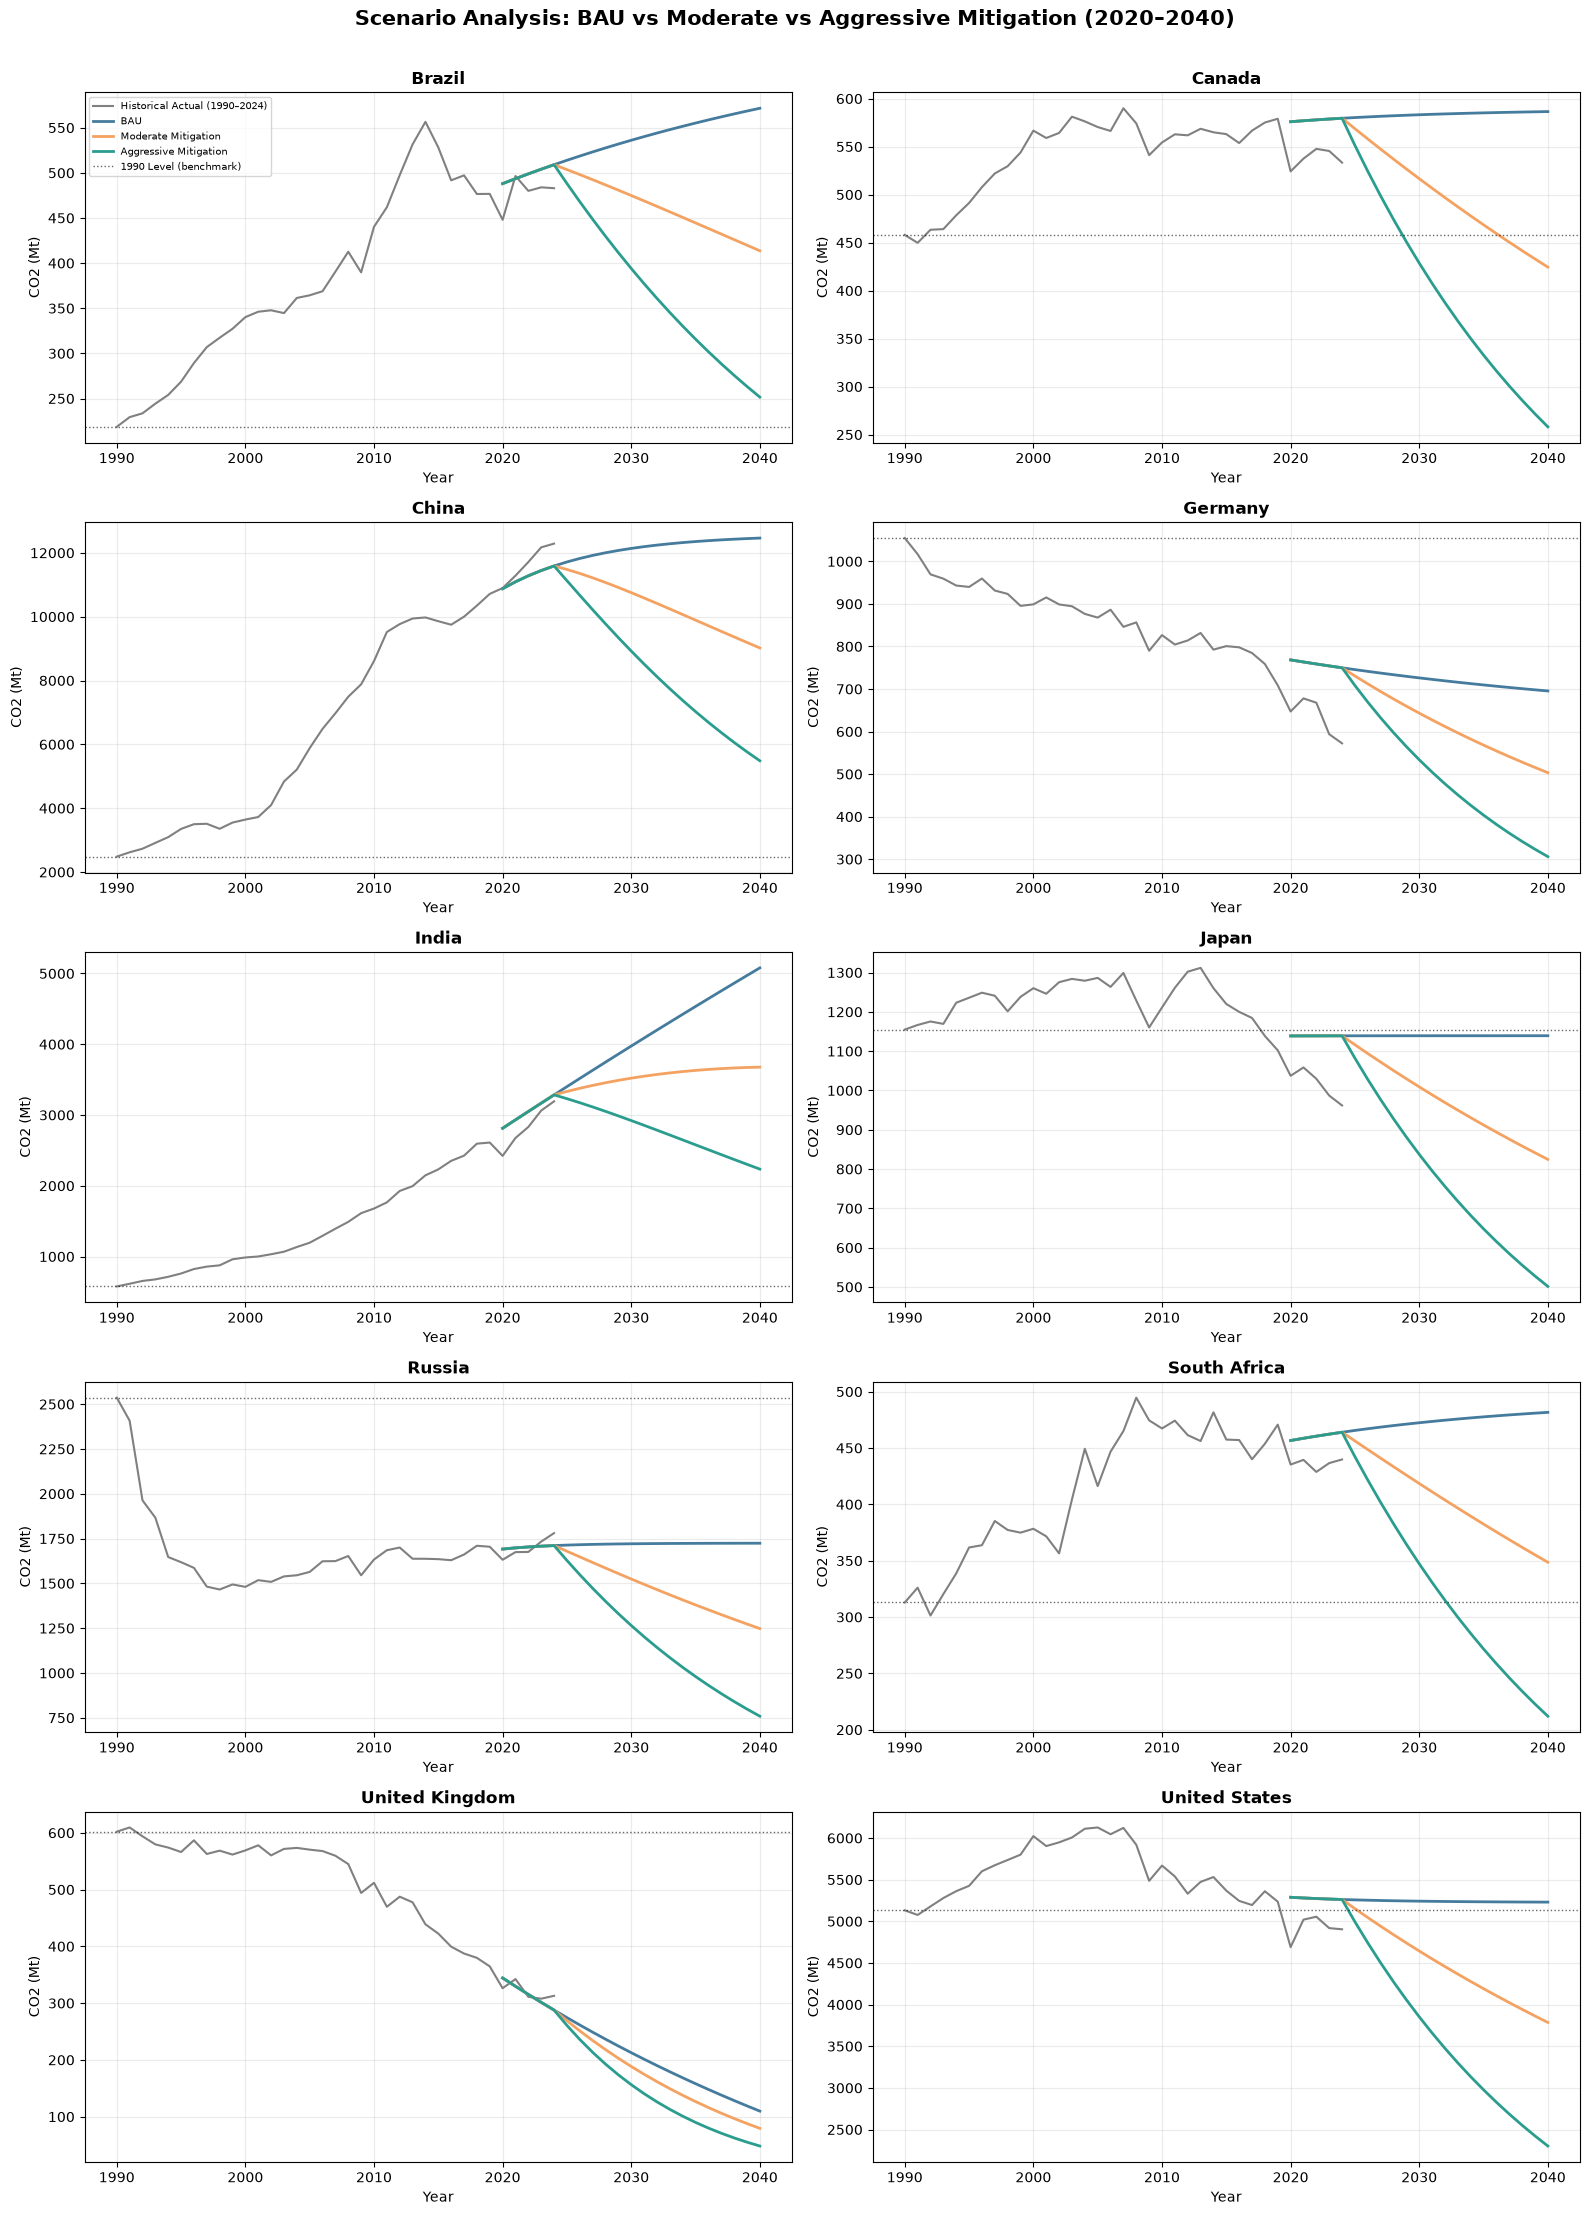

In [5]:
# ── Per-country overlay: historical actuals + 3 scenario lines + 1990 benchmark ──

scenario_colors = {'BAU': '#457B9D', 'Moderate Mitigation': '#F4A261', 'Aggressive Mitigation': '#2A9D8F'}

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, country in enumerate(PROJECT_COUNTRIES):
    ax = axes[i]

    hist = df_model[(df_model['country'] == country) & (df_model['year'].between(1990, 2024))].sort_values('year')
    ax.plot(hist['year'], hist['co2'], color='grey', linewidth=1.5, label='Historical Actual (1990–2024)')

    fc = bau_forecast[country]
    pre2025_years = [y for y in range(2020, 2025)]
    for scenario in REDUCTION_RATES:
        pre_vals = [fc.get(y, np.nan) for y in pre2025_years]  # scenarios haven't diverged yet before 2025
        scen_data = scenario_projections_df[
            (scenario_projections_df['country'] == country) & (scenario_projections_df['scenario'] == scenario)
        ].sort_values('year')
        plot_years = pre2025_years + scen_data['year'].tolist()
        plot_vals = pre_vals + scen_data['co2_projected'].tolist()
        ax.plot(plot_years, plot_vals, color=scenario_colors[scenario], linewidth=2, label=scenario)

    benchmark_1990 = df_model[(df_model['country'] == country) & (df_model['year'] == 1990)]['co2']
    if len(benchmark_1990):
        ax.axhline(benchmark_1990.values[0], color='black', linestyle=':', linewidth=1, alpha=0.6,
                   label='1990 Level (benchmark)')

    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('CO2 (Mt)')
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Scenario Analysis: BAU vs Moderate vs Aggressive Mitigation (2020–2040)', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

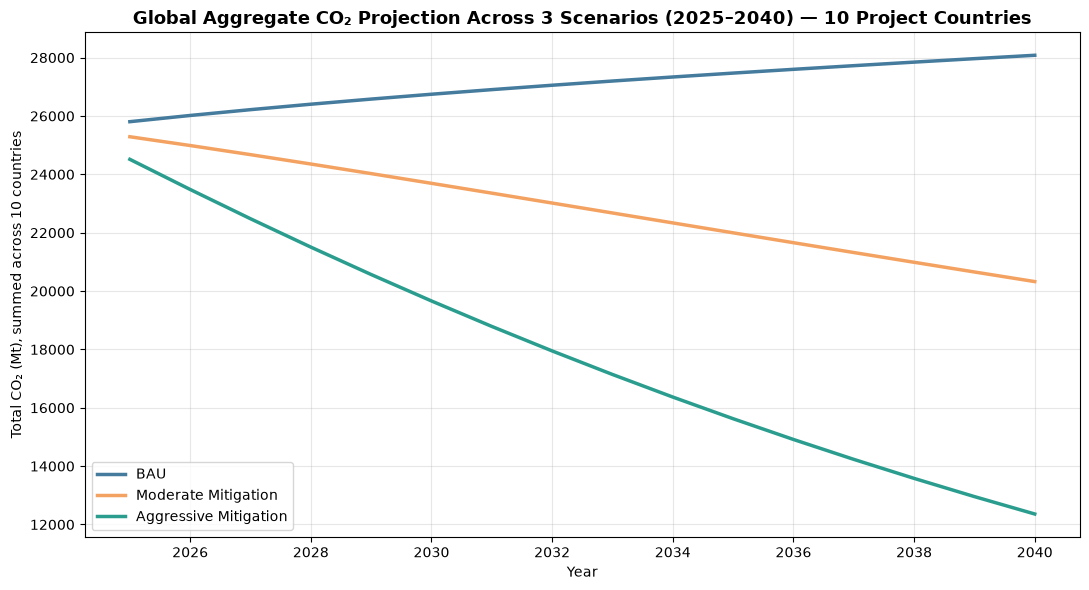

In [6]:
# ── Global aggregate chart: sum of all 10 countries per scenario ──

global_agg = (
    scenario_projections_df
    .groupby(['scenario', 'year'])['co2_projected']
    .sum()
    .reset_index()
)

plt.figure(figsize=(11, 6))
for scenario in REDUCTION_RATES:
    subset = global_agg[global_agg['scenario'] == scenario].sort_values('year')
    plt.plot(subset['year'], subset['co2_projected'], color=scenario_colors[scenario], linewidth=2.5, label=scenario)

plt.title('Global Aggregate CO₂ Projection Across 3 Scenarios (2025–2040) — 10 Project Countries', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total CO₂ (Mt), summed across 10 countries')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Impact Summary

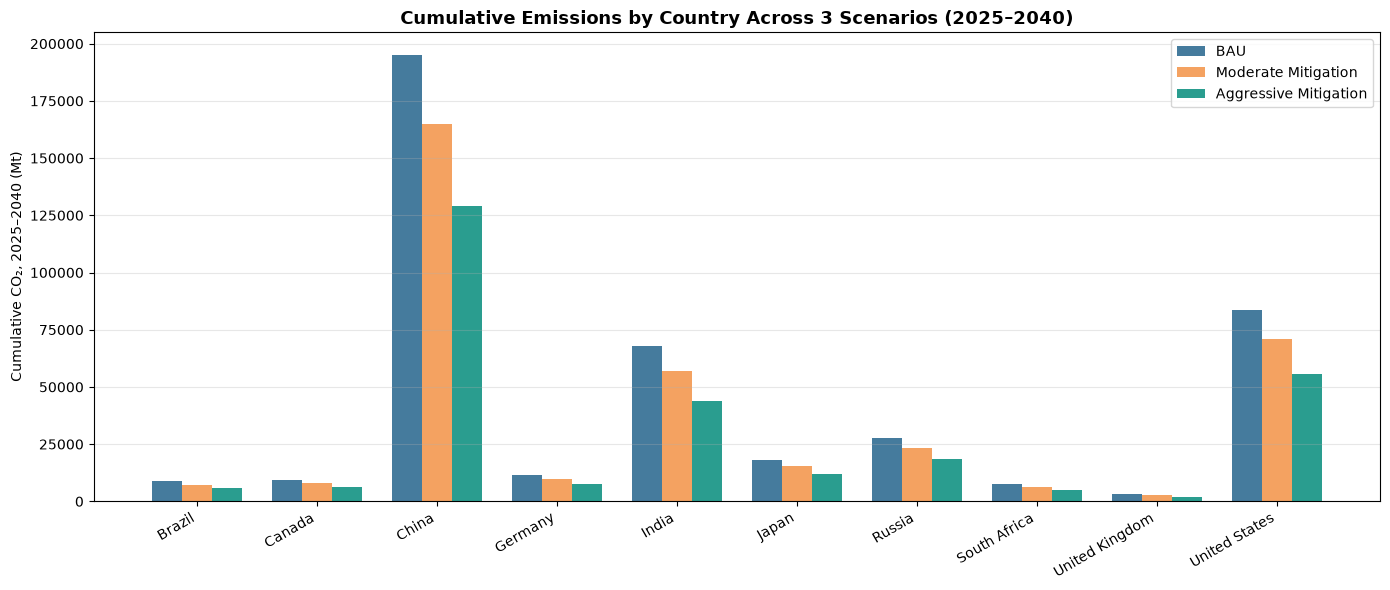

scenario,BAU,Moderate Mitigation,Aggressive Mitigation,BAU minus Aggressive (Mt avoided)
country,,,,
China,195194.03,164830.80,129215.92,65978.11
United States,83837.76,70925.74,55759.50,28078.26
India,68002.78,56872.20,43927.25,24075.53
Russia,27539.59,23291.28,18302.34,9237.25
Japan,18226.49,15417.16,12117.76,6108.73
Germany,11498.71,9745.82,7683.41,3815.30
Canada,9343.12,7900.69,6207.04,3136.08
Brazil,8716.69,7350.89,5751.05,2965.64
South Africa,7593.70,6417.11,5036.35,2557.35


In [7]:
cumulative_emissions = (
    scenario_projections_df
    .groupby(['country', 'scenario'])['co2_projected']
    .sum()
    .reset_index()
    .rename(columns={'co2_projected': 'cumulative_co2_2025_2040'})
)

cumulative_pivot = cumulative_emissions.pivot(index='country', columns='scenario', values='cumulative_co2_2025_2040')
cumulative_pivot = cumulative_pivot[['BAU', 'Moderate Mitigation', 'Aggressive Mitigation']]

x = np.arange(len(cumulative_pivot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for j, scenario in enumerate(cumulative_pivot.columns):
    ax.bar(x + (j - 1) * width, cumulative_pivot[scenario], width, label=scenario, color=scenario_colors[scenario])

ax.set_xticks(x)
ax.set_xticklabels(cumulative_pivot.index, rotation=30, ha='right')
ax.set_ylabel('Cumulative CO₂, 2025–2040 (Mt)')
ax.set_title('Cumulative Emissions by Country Across 3 Scenarios (2025–2040)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

cumulative_pivot['BAU minus Aggressive (Mt avoided)'] = cumulative_pivot['BAU'] - cumulative_pivot['Aggressive Mitigation']
cumulative_pivot.sort_values('BAU minus Aggressive (Mt avoided)', ascending=False)

**Interpretation — fill this in based on your actual `cumulative_pivot` output:**

Report which countries show the largest **absolute** avoided emissions (Mt) under Aggressive Mitigation versus BAU — these will typically be the countries with the highest BAU trajectory to begin with, since a flat 5% compounding cut removes more tonnage from a larger base. Separately, note whether the *ranking* changes if you instead look at **percentage** avoided rather than absolute Mt (a smaller emitter can show a large percentage benefit while still contributing little in absolute terms). State 2–3 sentences on which countries benefit most in absolute terms, which benefit most proportionally, and why those are not necessarily the same countries.